Copyright (c) Meta Platforms, Inc. and affiliates.
All rights reserved.

This source code is licensed under the license found in the
github repository of the project.

# Watermarking Autoregressive Image Generation

[[`arXiv`](https://arxiv.org/abs/...)]
[[`Github`](https://colab.research.google.com/github/facebookresearch/wmar/blob/main/notebooks/colab.ipynb)]

This notebook is a minimal working example to generate watermarked images with RAR as in [Watermarking Autoregressive Image Generation](https://github.com/facebookresearch/wmar).

## Setup

The setup code below installs the required packages to the active env and downloads the pre-trained model weights. 

Clone repo:

In [ ]:
!git clone https://github.com/facebookresearch/wmar.git
%cd wmar

Install requirements and download models:

In [ ]:
!pip install -U xformers --index-url https://download.pytorch.org/whl/cu126
!pip install -r requirements.txt
!pip install triton==3.1.0 

In [ ]:
!wget https://dl.fbaipublicfiles.com/watermark_anything/wam_mit.pth -P checkpoints/
!wget https://dl.fbaipublicfiles.com/wmar/finetunes/rar_encoder_ft_delta.pth -P checkpoints/finetunes/
!wget https://dl.fbaipublicfiles.com/wmar/finetunes/rar_decoder_ft_delta.pth -P checkpoints/finetunes/

## Load a model and generate some watermarked images

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch 

from wmar.models.rar_wrapper import RarARMMWrapper
from wmar.utils.utils import update_weights, add_code_to_plot
from wmar.watermarking.gentime_watermark import create_watermarker_from_string
from wmar.watermarking.synchronization import SyncManager
from wmar.augmentations.geometric import Rotate
from wmar.augmentations.valuemetric import JPEG

### Set up the autoregressive model and the watermarking framework.

This code loads the RAR model and updates the weights of the decoder and the encoder replica using deltas from RCC finetuning.
It also sets the watermarking parameters and sets up the synchonization layer.

(Note that in this example we use the small RAR-B variant; our experiments in the paper use the bigger RAR-XL)

In [3]:
# Load original model
model = RarARMMWrapper(modelpath = "checkpoints/", rar_size="rar_b")

# Patch and initialize the watermark
update_weights(model.get_image_tokenizer().encoder, "checkpoints/finetunes/rar_encoder_ft_delta.pth")
update_weights(model.get_image_tokenizer().decoder, "checkpoints/finetunes/rar_decoder_ft_delta.pth")
watermarker = create_watermarker_from_string(
    model.get_vq(), 
    model.get_total_vocab_size(), 
    "linear-stratifiedrand-h=1-d=2.0-g=0.25", 
    "cuda")
model.set_watermarker(watermarker)
sync_manager = SyncManager("checkpoints/wam_mit.pth", device="cuda")

/private/home/pfz/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/private/home/pfz/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth


2025-06-19 10:10:55.023 | DEBUG    | wmar.utils.utils:update_weights:66 - Missing: []
2025-06-19 10:10:55.024 | DEBUG    | wmar.utils.utils:update_weights:67 - Unexpected: []
2025-06-19 10:10:55.097 | DEBUG    | wmar.utils.utils:update_weights:66 - Missing: []
2025-06-19 10:10:55.098 | DEBUG    | wmar.utils.utils:update_weights:67 - Unexpected: []


Loaded alive ids: 1024
Codes size: 16, Image size: 256, Dim z: 256
Greenlist size: 256 for vocab sz 1024 and gamma 0.25
making attention of type 'vanilla' with 64 in_channels
Working with z of shape (1, 68, 32, 32) = 69632 dimensions.
making attention of type 'vanilla' with 64 in_channels
Model loaded successfully from checkpoints/wam_mit.pth
{'embedder_config': 'deps/watermark_anything/configs/embedder.yaml', 'augmentation_config': 'deps/watermark_anything/configs/all_augs_multi_wm.yaml', 'extractor_config': 'deps/watermark_anything/configs/extractor.yaml', 'attenuation_config': 'deps/watermark_anything/configs/attenuation.yaml', 'embedder_model': 'vae_small', 'extractor_model': 'sam_base', 'nbits': 32, 'img_size': 256, 'img_size_extractor': 256, 'attenuation': 'jnd_1_3_blue', 'scaling_w': 2.0, 'scaling_w_schedule': None, 'scaling_i': 1.0, 'roll_probability': 0.2, 'multiple_w': 1.0, 'nb_wm_eval': 5, 'optimizer': 'AdamW,lr=1e-4', 'optimizer_d': None, 'scheduler': 'CosineLRScheduler,lr_

### Generate images with RAR-B conditioned on the ImageNet class 975 ("Lakeside").

We generate an unwatermarked image and a watermarked image, and run the watermark detector on both, as well as the transformed variants of the watermarked image (JPEG, rotation).

The rightmost column illustrates the tokens ultimately received by the watermark detector. These should be interpreted as follows:
- The **shape** (square 🟥 or cross ❌) indicates if the token is reverse cycle-consistent. Every square token *matches the token that was originally generated by the model at that position* while every cross token does not. 
- Independently, the **color** (green 🟩, red 🟥, white ⬜) indicates the color assigned to the token by the watermark detector following the rules of the Red/Green scheme. White tokens are those that are ignored by the detector due to duplication or insufficient context.

We see that watermarked images have more green tokens and are detected as watermarked (*low p-values*) even after augmentations.

/private/home/pfz/11-autoregressive/release/wmar/models/rar_wrapper.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conditioning = torch.tensor(conditioning, device=self.model.device).view(-1, 1)
2025-06-19 10:11:00.759 | WARNING  | wmar.watermarking.synchronization:estimate_augmentation_with_wam:298 - idx=0: Total size is 0<45875; I am not confident enough in WAM, returning dummy values
2025-06-19 10:11:00.760 | INFO     | wmar.watermarking.synchronization:remove_wam:100 - 0: 4 messages found | Rot: 0, cuts: 128, 128 (flip=False)


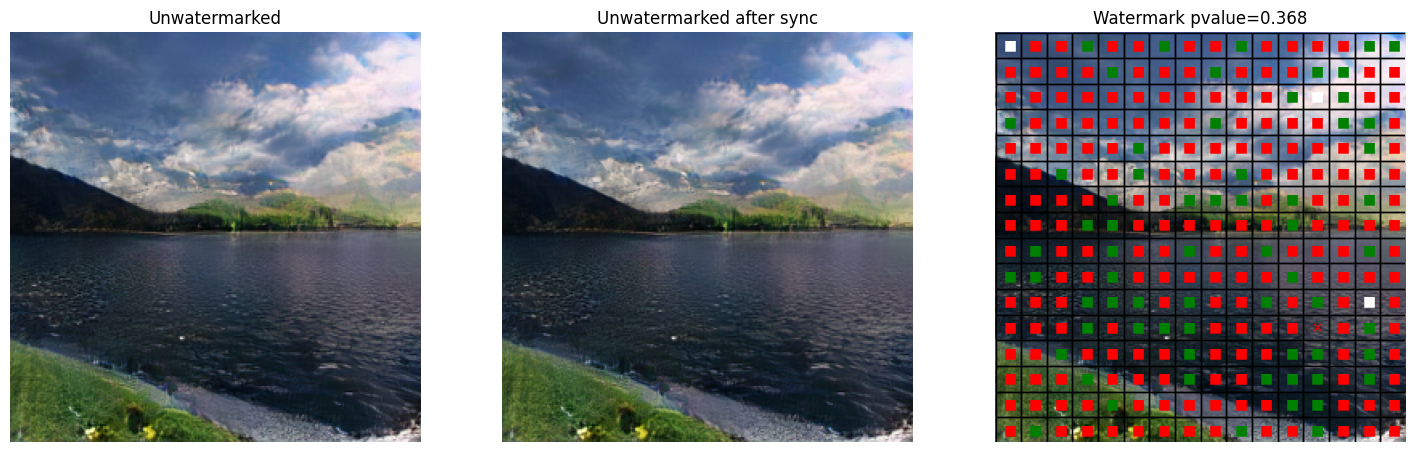

2025-06-19 10:11:07.311 | INFO     | wmar.watermarking.synchronization:remove_wam:100 - 0: 4 messages found | Rot: 0, cuts: 128, 127 (flip=False)


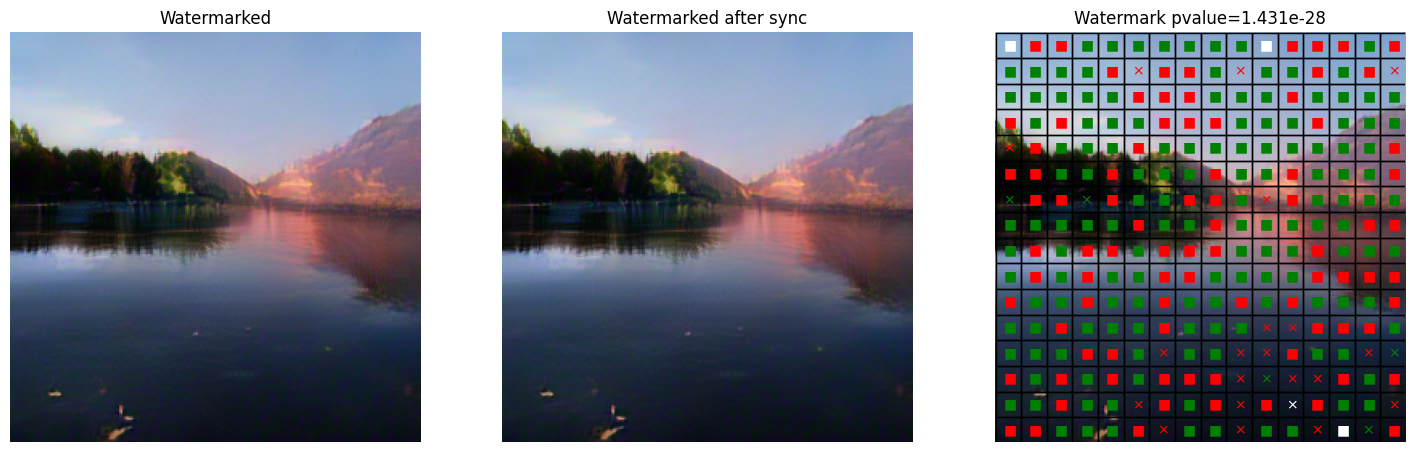

2025-06-19 10:11:09.516 | INFO     | wmar.watermarking.synchronization:remove_wam:100 - 0: 4 messages found | Rot: -10, cuts: 126, 126 (flip=False)


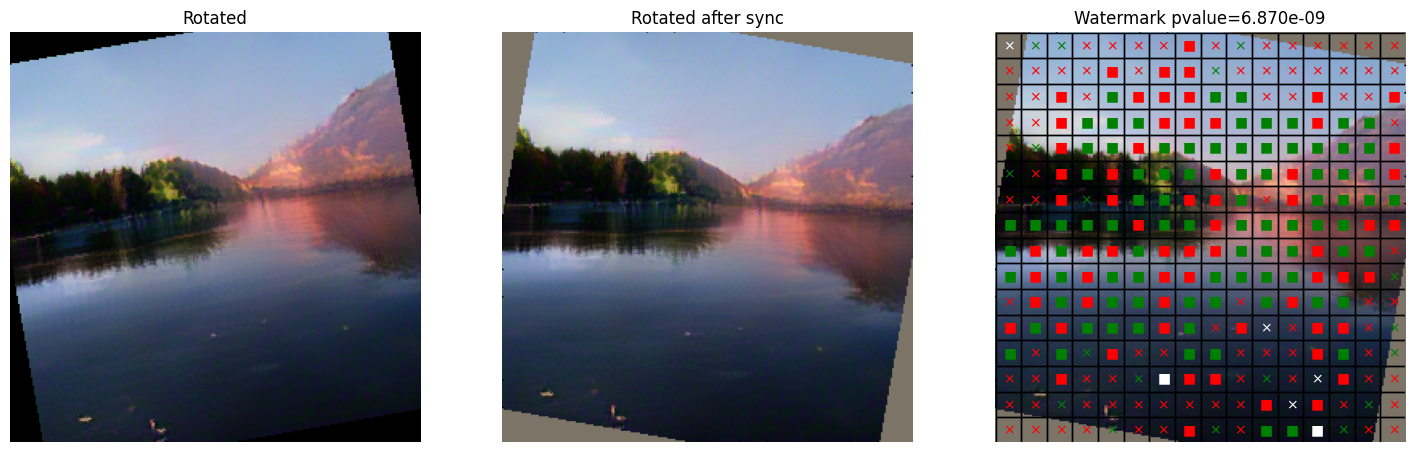

2025-06-19 10:11:10.459 | WARNING  | wmar.watermarking.synchronization:estimate_augmentation_with_wam:298 - idx=0: Total size is 0<45875; I am not confident enough in WAM, returning dummy values
2025-06-19 10:11:10.460 | INFO     | wmar.watermarking.synchronization:remove_wam:100 - 0: 4 messages found | Rot: 0, cuts: 128, 128 (flip=False)


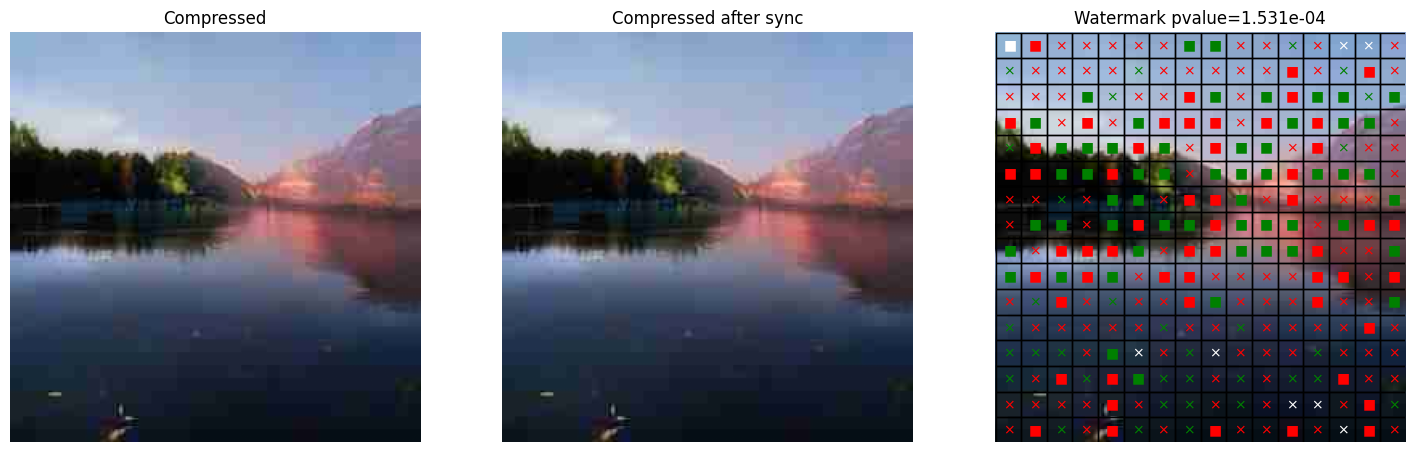

In [4]:
seed = 13
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

def img2np(img):
    return (img/2.0+0.5).permute(1, 2, 0).cpu().numpy()

def show(key, orig_codes, imgs, model, watermarker, sync_manager):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img2np(imgs[0]))
    plt.axis('off')
    plt.title(f"{key}")

    plt.subplot(1, 3, 2)
    imgs_nosync = sync_manager.remove_wam(imgs)
    plt.imshow(img2np(imgs_nosync[0]))
    plt.axis('off')
    plt.title(f"{key} after sync")

    plt.subplot(1, 3, 3)    
    plt.imshow(img2np(imgs_nosync[0]))
    codes = model.images_to_codes(imgs_nosync).detach()
    pval = watermarker.detect(codes)[0].cpu().item()
    add_code_to_plot(orig_codes[0], codes[0], watermarker)
    plt.axis('off')
    if pval > 0.01:
        plt.title(f"Watermark pvalue={pval:.3f}")
    else:
        plt.title(f"Watermark pvalue={pval:.3e}")
    plt.show()


gen_params = {"batch_size": 1, "temperature": 0.8, "top_k": 250, "top_p": 0.92}
class_conditioning = torch.tensor([[975]]) # Lakeside
# Generate some nowm images 
nowm_codes = model.sample(class_conditioning, gen_params, apply_watermark=False).detach()
nowm_imgs = model.codes_to_images(nowm_codes).detach()
show("Unwatermarked", nowm_codes, nowm_imgs, model, watermarker, sync_manager)

# Sample and decode to image 
orig_codes = model.sample(class_conditioning, gen_params, apply_watermark=True).detach()
orig_imgs = model.codes_to_images(orig_codes).detach()
orig_imgs_with_sync = sync_manager.add_wam(orig_imgs).detach()
show("Watermarked", orig_codes, orig_imgs_with_sync, model, watermarker, sync_manager)

# Augmentations? 
def apply_augmentation(imgs, aug_fn, aug_param):
    return aug_fn(imgs/2.0+0.5, aug_param).clamp(0, 1)*2.0-1.0

rotated = apply_augmentation(orig_imgs_with_sync, Rotate(), 10)
show("Rotated", orig_codes, rotated, model, watermarker, sync_manager)

noised = apply_augmentation(orig_imgs_with_sync, JPEG(), 20)
show("Compressed", orig_codes, noised, model, watermarker, sync_manager)